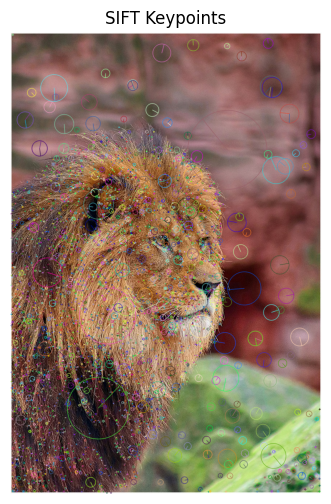

Number of Keypoints = 4843


In [4]:
import cv2
import matplotlib.pyplot as plt

# Read image
img = cv2.imread("mani2.jpg")

# Convert to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Create SIFT detector
sift = cv2.SIFT_create()

# Detect keypoints and descriptors
keypoints, descriptors = sift.detectAndCompute(gray, None)

# Draw keypoints
result = cv2.drawKeypoints(
    img,
    keypoints,
    None,
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)

# Convert BGR to RGB
result = cv2.cvtColor(result, cv2.COLOR_BGR2RGB)

# Display
plt.figure(figsize=(10,6))
plt.imshow(result)
plt.title("SIFT Keypoints")
plt.axis("off")
plt.show()

print("Number of Keypoints =", len(keypoints))

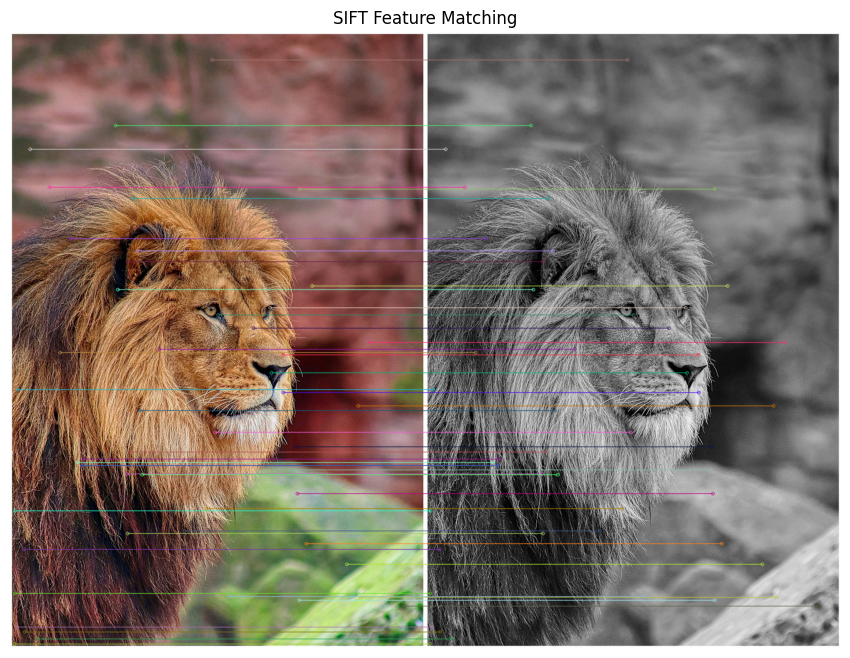

Keypoints in Image 1 = 4843
Keypoints in Image 2 = 4792
Total Matches = 4843


In [7]:
import cv2
import matplotlib.pyplot as plt

# Read images
img1 = cv2.imread("mani2.jpg")
img2 = cv2.imread("mani2_bw.jpg")

# Convert to grayscale
gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

# Create SIFT object
sift = cv2.SIFT_create()

# Detect keypoints and descriptors
kp1, des1 = sift.detectAndCompute(gray1, None)
kp2, des2 = sift.detectAndCompute(gray2, None)

# Brute Force Matcher
bf = cv2.BFMatcher(cv2.NORM_L2)

# Match descriptors
matches = bf.match(des1, des2)

# Sort matches by distance
matches = sorted(matches, key=lambda x: x.distance)

# Draw best 50 matches
result = cv2.drawMatches(
    img1,
    kp1,
    img2,
    kp2,
    matches[:50],
    None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)

# Convert to RGB
result = cv2.cvtColor(result, cv2.COLOR_BGR2RGB)

# Display
plt.figure(figsize=(15,8))
plt.imshow(result)
plt.title("SIFT Feature Matching")
plt.axis("off")
plt.show()

print("Keypoints in Image 1 =", len(kp1))
print("Keypoints in Image 2 =", len(kp2))
print("Total Matches =", len(matches))